Purpose: Check if there is any correlation between sample number and number of time-structured genes for different genotypes.<br>
Author: Anna Pardo<br>
Date initiated: Dec. 2, 2025

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import os

In [2]:
plotc = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/masigpro_results/clusters_ngenes_gt_ztgroup_with36-61-43.txt",
                    sep="\t",header="infer")
plotc.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0.0,319,53_1,5.0
1,2,53,1.0,656,53_2,21.0
2,3,53,1.0,882,53_3,17.0
3,4,53,0.0,1071,53_4,9.0
4,5,53,0.0,428,53_5,21.0


In [3]:
# load metadata (off TPM)
md = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/masigpro_results/metadata_from_TPM_ztsub.txt",sep="\t",header="infer")
md.head()

,sample_name,genotype,treat,ZT
0,Y1,18,W,1.0
1,Y101,2AB,D,1.0
2,Y103,2AB,D,1.0
3,Y104,1AB,W,21.0
4,Y105,18,W,21.0


In [4]:
md["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [5]:
plotc["genotype"].unique()

array(['53', 'Eudy', '13', '52', '48', 'G', '19', '46', '56', '45', '18',
       '70', '1AB', '55', '51', '2AB', '37', 'all', '36', '61', '43'],
      dtype=object)

In [6]:
md["condition"] = md["treat"]+"_"+md["ZT"].astype(str)
md.head()

,sample_name,genotype,treat,ZT,condition
0,Y1,18,W,1.0,W_1.0
1,Y101,2AB,D,1.0,D_1.0
2,Y103,2AB,D,1.0,D_1.0
3,Y104,1AB,W,21.0,W_21.0
4,Y105,18,W,21.0,W_21.0


In [8]:
# drop 'all' from plotc
plotc = plotc[plotc["genotype"]!="all"]

In [9]:
# for each genotype in plotc, find the number of samples in md
## also find the mean number of reps
def find_nsamp(gt):
    gtmd = md[md["genotype"]==gt]
    nsamp = len(gtmd["sample_name"].unique())
    # to find number of reps, make a summary table on condition col
    csum = gtmd.groupby("condition").count().reset_index()[["condition","sample_name"]].rename(columns={"sample_name":"nreps"})
    if len(csum.index)>0:
        meanreps = sum(csum["nreps"])/len(csum.index)
    else:
        meanreps = 0
    return [nsamp,int(round(meanreps,0))]

In [10]:
dfdict = {"genotype":[],"n_samples":[],"mean_reps":[]}
for g in list(plotc["genotype"].unique()):
    dfdict['genotype'].append(g)
    l = find_nsamp(g)
    dfdict['n_samples'].append(l[0])
    dfdict['mean_reps'].append(l[1])
nsmr = pd.DataFrame(dfdict)

In [11]:
# add in information about the total number of time-structured genes for each genotype
def total_ts_gt(gt):
    gtinfo = plotc[plotc["genotype"]==gt]
    return sum(gtinfo["n_all_genes"])

In [12]:
total = []
for i in nsmr["genotype"].unique():
    total.append(total_ts_gt(i))
nsmr["total_ts_genes"] = total
nsmr.head()

,genotype,n_samples,mean_reps,total_ts_genes
0,53,17,2,4133
1,Eudy,25,2,8871
2,13,34,3,3890
3,52,25,2,6178
4,48,23,2,6963


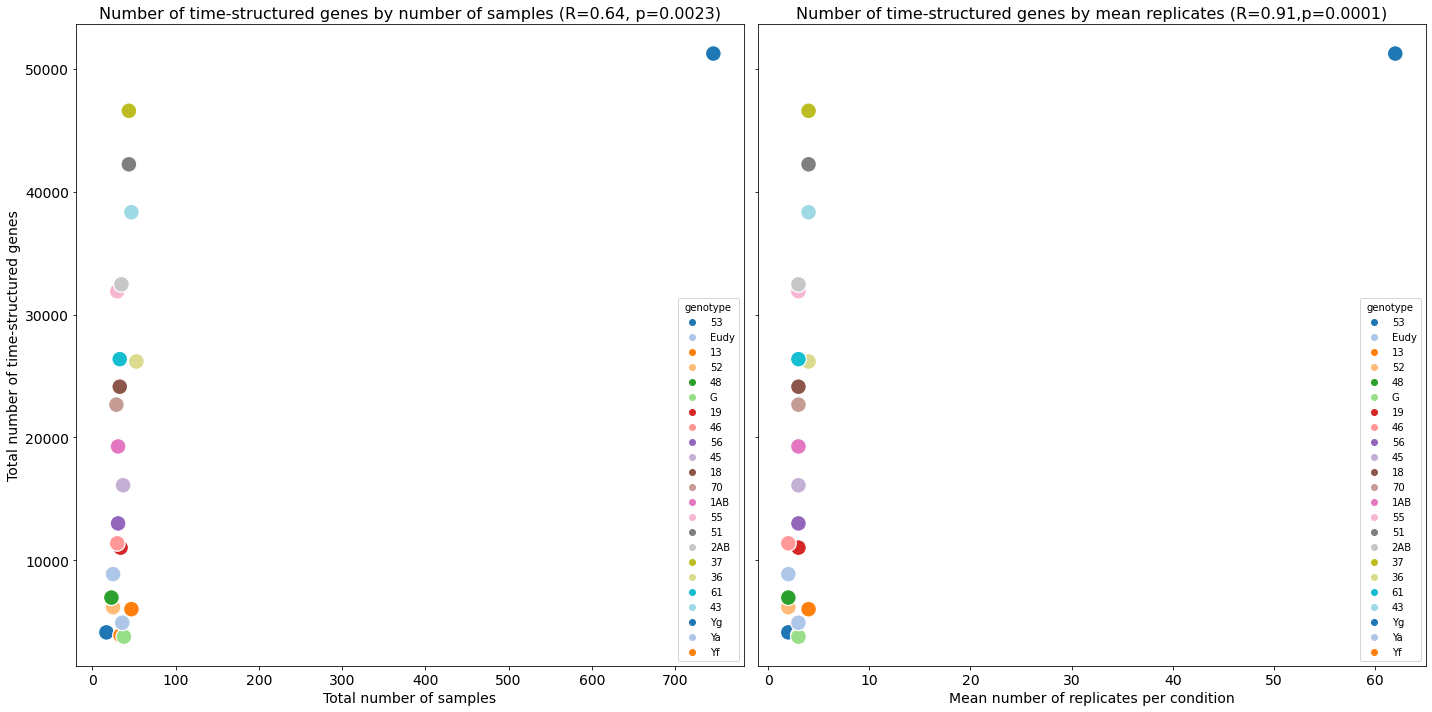

In [57]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,10),sharey=True)

sns.scatterplot(ax=ax[0],data=nsmr,y="total_ts_genes",x="n_samples",hue="genotype",palette="tab20",s=250)
ax[0].set_xlabel("Total number of samples",fontsize=14)
ax[0].set_ylabel("Total number of time-structured genes",fontsize=14)
ax[0].tick_params(axis="both",which="major",labelsize=14)
ax[0].set_title("Number of time-structured genes by number of samples (R=0.64, p=0.0023)",fontsize=16)

sns.scatterplot(ax=ax[1],data=nsmr,y="total_ts_genes",x="mean_reps",hue="genotype",palette="tab20",s=250)
ax[1].set_xlabel("Mean number of replicates per condition",fontsize=14)
ax[1].tick_params(axis="x",which="major",labelsize=14)
ax[1].set_xticks(np.arange(2,5,1))
ax[1].set_title("Number of time-structured genes by mean replicates (R=0.91,p=0.0001)",fontsize=16)

fig.tight_layout()

plt.savefig("./tsgenes_by_nsamp_meanreps.png",dpi=300,bbox_inches="tight")
plt.savefig("./tsgenes_by_nsamp_meanreps.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./tsgenes_by_nsamp_meanreps.svg",dpi=300,bbox_inches="tight")

In [17]:
# now run the correlation - get both R & p-values
nsmr.corr("pearson")

,n_samples,mean_reps,total_ts_genes
n_samples,1.000000,0.907270,0.640734
mean_reps,0.907270,1.000000,0.775555
total_ts_genes,0.640734,0.775555,1.000000


In [18]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

In [19]:
calculate_pvalues(nsmr[["total_ts_genes","n_samples","mean_reps"]])

,total_ts_genes,n_samples,mean_reps
total_ts_genes,0.0,0.0023,0.0001
n_samples,0.0023,0.0,0.0
mean_reps,0.0001,0.0,0.0


In [23]:
nsmr.head()

,genotype,n_samples,mean_reps,total_ts_genes
0,53,17,2,4133
1,Eudy,25,2,8871
2,13,34,3,3890
3,52,25,2,6178
4,48,23,2,6963


In [24]:
min(nsmr["total_ts_genes"])

3783

In [25]:
max(nsmr["total_ts_genes"])

46583

In [26]:
nsmr.sort_values(by="total_ts_genes",ascending=True)

,genotype,n_samples,mean_reps,total_ts_genes
5,G,38,3,3783
2,13,34,3,3890
0,53,17,2,4133
3,52,25,2,6178
4,48,23,2,6963
1,Eudy,25,2,8871
6,19,34,3,11028
7,46,30,2,11380
8,56,31,3,13002
9,45,37,3,16106


## Apr. 9, 2026: Re-run this correlation for all runs (include Ya & Yf as well as recent Yg single-replicates per condition run)

In [27]:
resyg = pd.read_csv("./hck6_Yg_singlereps.tsv",sep="\t",header="infer")
resyg.head()

,cluster,GeneID
0,1,Yucal.01G000100.v2.1
1,2,Yucal.01G000200.v2.1
2,2,Yucal.01G000400.v2.1
3,1,Yucal.01G000500.v2.1
4,2,Yucal.01G000600.v2.1


In [28]:
yares = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/masigpro_results/Ya_hclust_k6_clusters.txt",
                   sep="\t",header="infer")
yfres = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/masigpro_results/Yf_hclust_k6_clusters.txt",
                   sep="\t",header="infer")

In [45]:
yares.head()

,cluster,GeneID
0,1,Yucal.01G000500.v2.1
1,2,Yucal.01G000900.v2.1
2,3,Yucal.01G001300.v2.1
3,3,Yucal.01G001400.v2.1
4,4,Yucal.01G002500.v2.1


In [32]:
# load parental metadata
mddir = "/home/leviathan22/Yucca_genomics/rna_reanalysis_30-Jun-2025/TPM"

In [35]:
yamd = pd.read_csv(os.path.join(mddir,"Yalo_TPM_withmd_July2025.txt"),sep="\t",header="infer",usecols=["sample_name","genotype",
                                                                                                       "treat","ZT","species"])
yamd.head()

,sample_name,genotype,treat,ZT,species
0,X39,7.0,D,1.0,aloifolia
1,X40,7.0,D,21.0,aloifolia
2,X41,7.0,W,1.0,aloifolia
3,X42,7.0,W,21.0,aloifolia
4,X47,7.0,D,5.0,aloifolia


In [36]:
yfmd = pd.read_csv(os.path.join(mddir,"YfilH1_TPM_withmd_July2025.txt"),sep="\t",header="infer",
                  usecols=["sample_name","genotype","treat","ZT","species"])
yfmd.head()

,sample_name,genotype,treat,ZT,species
0,X73,2.0,D,13.0,filamentosa
1,X74,2.0,D,17.0,filamentosa
2,X64,2.0,W,5.0,filamentosa
3,X101,27.0,D,9.0,filamentosa
4,X102,27.0,D,1.0,filamentosa


In [38]:
nsamp = len(yamd["sample_name"].unique())
yamd["condition"] = yamd["treat"]+"_"+yamd["ZT"].astype(str)
# to find number of reps, make a summary table on condition col
csum = yamd.groupby("condition").count().reset_index()[["condition","sample_name"]].rename(columns={"sample_name":"nreps"})
if len(csum.index)>0:
    meanreps = sum(csum["nreps"])/len(csum.index)
else:
    meanreps = 0
yainfo = [nsamp,int(round(meanreps,0))]

In [40]:
nsamp = len(yfmd["sample_name"].unique())
yfmd["condition"] = yfmd["treat"]+"_"+yfmd["ZT"].astype(str)
# to find number of reps, make a summary table on condition col
csum = yfmd.groupby("condition").count().reset_index()[["condition","sample_name"]].rename(columns={"sample_name":"nreps"})
if len(csum.index)>0:
    meanreps = sum(csum["nreps"])/len(csum.index)
else:
    meanreps = 0
yfinfo = [nsamp,int(round(meanreps,0))]

In [41]:
md.head()

,sample_name,genotype,treat,ZT,condition
0,Y1,18,W,1.0,W_1.0
1,Y101,2AB,D,1.0,D_1.0
2,Y103,2AB,D,1.0,D_1.0
3,Y104,1AB,W,21.0,W_21.0
4,Y105,18,W,21.0,W_21.0


In [42]:
nsamp = len(md["sample_name"].unique())
# to find number of reps, make a summary table on condition col
csum = md.groupby("condition").count().reset_index()[["condition","sample_name"]].rename(columns={"sample_name":"nreps"})
if len(csum.index)>0:
    meanreps = sum(csum["nreps"])/len(csum.index)
else:
    meanreps = 0
yginfo = [nsamp,int(round(meanreps,0))]

In [46]:
dfdict = {
    "genotype":["Yg","Ya","Yf"],
    "n_samples":[yginfo[0],yainfo[0],yfinfo[0]],
    "mean_reps":[yginfo[1],yainfo[1],yfinfo[1]],
    "total_ts_genes":[len(resyg["GeneID"].unique()),len(yares["GeneID"].unique()),len(yfres["GeneID"].unique())]
}
spinfo = pd.DataFrame(dfdict)

In [48]:
nsmr = pd.concat([nsmr,spinfo])

In [49]:
nsmr.corr("pearson")

,n_samples,mean_reps,total_ts_genes
n_samples,1.000000,0.999737,0.486103
mean_reps,0.999737,1.000000,0.491649
total_ts_genes,0.486103,0.491649,1.000000


In [50]:
calculate_pvalues(nsmr[["total_ts_genes","n_samples","mean_reps"]])

,total_ts_genes,n_samples,mean_reps
total_ts_genes,0.0,0.0187,0.0172
n_samples,0.0187,0.0,0.0
mean_reps,0.0172,0.0,0.0


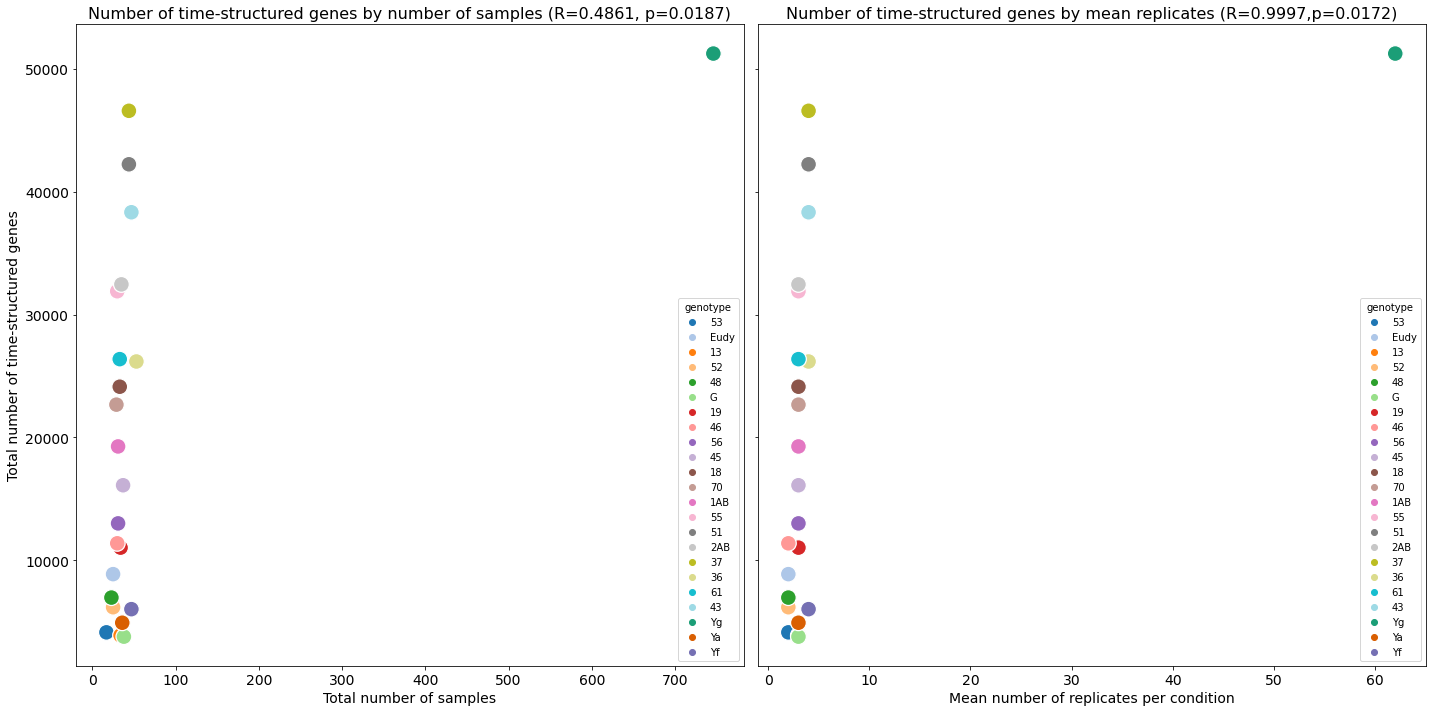

In [59]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,10),sharey=True)

sns.scatterplot(ax=ax[0],data=nsmr[~nsmr["genotype"].isin(["Yg","Ya","Yf"])],y="total_ts_genes",
                                                         x="n_samples",hue="genotype",palette="tab20",s=250)
sns.scatterplot(ax=ax[0],data=spinfo,y="total_ts_genes",x="n_samples",hue="genotype",palette="Dark2",s=250)
ax[0].set_xlabel("Total number of samples",fontsize=14)
ax[0].set_ylabel("Total number of time-structured genes",fontsize=14)
ax[0].tick_params(axis="both",which="major",labelsize=14)
ax[0].set_title("Number of time-structured genes by number of samples (R=0.4861, p=0.0187)",fontsize=16)

sns.scatterplot(ax=ax[1],data=nsmr[~nsmr["genotype"].isin(["Yg","Ya","Yf"])],
                y="total_ts_genes",x="mean_reps",hue="genotype",palette="tab20",s=250)
sns.scatterplot(ax=ax[1],data=spinfo,y="total_ts_genes",x="mean_reps",hue="genotype",palette="Dark2",s=250)
ax[1].set_xlabel("Mean number of replicates per condition",fontsize=14)
ax[1].tick_params(axis="x",which="major",labelsize=14)
#ax[1].set_xticks(np.arange(2,5,1))
ax[1].set_title("Number of time-structured genes by mean replicates (R=0.9997,p=0.0172)",fontsize=16)

fig.tight_layout()

plt.savefig("./tsgenes_by_nsamp_meanreps_withsp.png",dpi=300,bbox_inches="tight")
plt.savefig("./tsgenes_by_nsamp_meanreps_withsp.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./tsgenes_by_nsamp_meanreps_withsp.svg",dpi=300,bbox_inches="tight")

In [60]:
spinfo

,genotype,n_samples,mean_reps,total_ts_genes
0,Yg,746,62,51243
1,Ya,36,3,4915
2,Yf,47,4,6021


In [61]:
nsmr2 = nsmr[~nsmr["genotype"].isin(["Yg","Ya","Yf"])]

In [62]:
nsmr2.head()

,genotype,n_samples,mean_reps,total_ts_genes
0,53,17,2,4133
1,Eudy,25,2,8871
2,13,34,3,3890
3,52,25,2,6178
4,48,23,2,6963


(array([5., 3., 2., 1., 2., 2., 2., 0., 2., 1.]),
 array([ 3783.,  8063., 12343., 16623., 20903., 25183., 29463., 33743.,
        38023., 42303., 46583.]),
 <BarContainer object of 10 artists>)

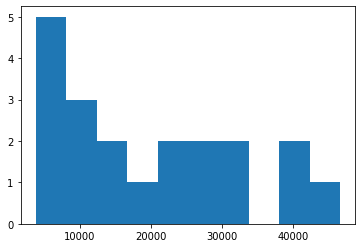

In [63]:
plt.hist(nsmr2["total_ts_genes"])